In [1]:
# Cell 1: Upload file gambar
from IPython.display import display
import numpy as np
import io
from matplotlib import pyplot as plt
from IPython.display import Image
from ipywidgets import FileUpload

upload = FileUpload(accept='image/*', multiple=False)
display(upload)


FileUpload(value=(), accept='image/*', description='Upload')

In [7]:
def read_image(upload):
    if len(upload.value) == 0:
        print("Silakan upload gambar terlebih dahulu.")
        return None

    # Mengakses file upload yang ada dalam tuple
    file_info = upload.value[0]  # Akses item pertama (karena hanya satu file)
    
    image_data = plt.imread(io.BytesIO(file_info['content']))
    if image_data.dtype == np.float32 or image_data.dtype == np.float64:
        image_data = (image_data * 255).astype(np.uint8)
    
    return image_data


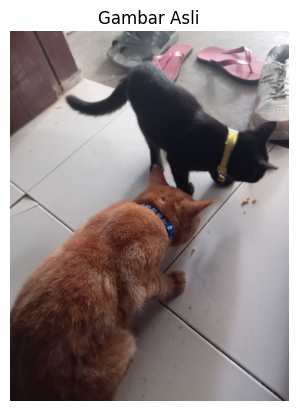

In [8]:
# Cell 2: Membaca gambar yang diupload dan menampilkannya
if len(upload.value) > 0:  # Mengecek apakah ada file yang diupload
    image_data = read_image(upload)  # Panggil fungsi untuk membaca gambar
    
    if image_data is not None:
        plt.imshow(image_data)
        plt.axis('off')  # Menghilangkan axis
        plt.title("Gambar Asli")
        plt.show()  # Menampilkan gambar yang diupload
    else:
        print("Gagal memuat gambar.")
else:
    print("Silakan upload gambar terlebih dahulu.")


In [10]:
def to_grayscale(img):
    height = len(img)
    width = len(img[0])
    gray_img = []

    for i in range(height):
        row = []
        for j in range(width):
            pixel = img[i][j]
            if len(pixel) >= 3:
                r = int(pixel[0])
                g = int(pixel[1])
                b = int(pixel[2])
                gray = (r + g + b) // 3
                row.append(gray)
            else:
                row.append(int(pixel[0]))  # Sudah grayscale
        gray_img.append(row)

    return gray_img


Gambar berhasil dimuat!


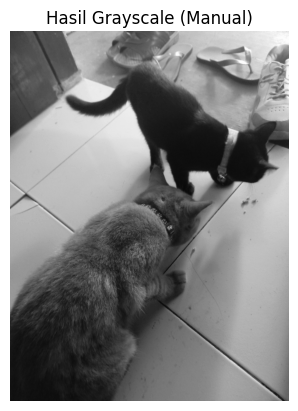

In [11]:
# Pastikan gambar berhasil dibaca
img = read_image(upload)

# Jika gambar valid, konversi ke grayscale
if img is not None:
    print("Gambar berhasil dimuat!")
    
    # Konversi grayscale manual
    gray = to_grayscale(img)
    
    # Tampilkan hasilnya
    plt.imshow(gray, cmap='gray')
    plt.title("Hasil Grayscale (Manual)")
    plt.axis('off')
    plt.show()
else:
    print("Gagal memuat gambar.")
